# Linear Regression from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

Linear regression models the relationship between a continuous target variable and one or more input features. This implementation supports three methods:

1. **OLS** (Ordinary Least Squares) — solves the normal equation directly: $\theta = (X^T X)^{-1} X^T y$
2. **Ridge Regression** — adds L2 regularization to reduce overfitting: $\theta = (X^T X + \alpha I)^{-1} X^T y$
3. **Gradient Descent** — iteratively updates weights to minimize MSE

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.linear_regression import LinearRegression
from rice_ml.processing.metrics import mean_squared_error, r2_score
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Diabetes dataset**: 442 patients with 10 physiological features. The target is a quantitative measure of diabetes progression one year after baseline.

In [11]:
data = load_diabetes()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Target range: {y.min():.1f} to {y.max():.1f}")
print(f"Feature names: {data.feature_names}")

Dataset shape: (442, 10)
Target range: 25.0 to 346.0
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Preprocessing and Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 353
Test samples: 89


## 3.1 Ordinary Least Squares (OLS — Closed Form)

OLS solves the Normal Equation directly, giving the mathematically exact solution for unregularized linear regression.

In [13]:
ols_model = LinearRegression(method='ols')
print("Beginning OLS Training (Closed-Form Solution)...")
ols_model.fit(X_train_scaled, y_train)

r2_ols = ols_model.score(X_test_scaled, y_test)
print("Training Complete.")
print(f"OLS R² Score: {r2_ols:.4f}")
print(f"Intercept: {ols_model.intercept_:.2f}")

Beginning OLS Training (Closed-Form Solution)...
Training Complete.
OLS R² Score: 0.4526
Intercept: 153.74


## 3.2 Ridge Regression (Closed Form with L2 Penalty)

Ridge adds a regularization penalty (alpha) to stabilize the solution and reduce the magnitude of coefficients, helping prevent overfitting.

In [14]:
ridge_model = LinearRegression(method='ridge', alpha=10.0)
print("Beginning Ridge Training (Closed-Form with L2 Penalty)...")
ridge_model.fit(X_train_scaled, y_train)

r2_ridge = ridge_model.score(X_test_scaled, y_test)
print("Training Complete.")
print(f"Ridge R² Score: {r2_ridge:.4f}")

Beginning Ridge Training (Closed-Form with L2 Penalty)...
Training Complete.
Ridge R² Score: 0.4572


## 3.3 Gradient Descent (Iterative Solution)

Gradient Descent iteratively updates weights using the learning rate to minimize mean squared error. This requires feature scaling.

In [15]:
gd_model = LinearRegression(method='gd', learning_rate=0.01, max_iter=1000)
print("Beginning Gradient Descent Training...")
gd_model.fit(X_train_scaled, y_train)

r2_gd = gd_model.score(X_test_scaled, y_test)
print("Training Complete.")
print(f"Gradient Descent R² Score: {r2_gd:.4f}")

Beginning Gradient Descent Training...
Training Complete.
Gradient Descent R² Score: 0.4555


## Comparing All Three Methods

OLS                       R² = 0.4526
Ridge (α=10)              R² = 0.4572
Gradient Descent          R² = 0.4555


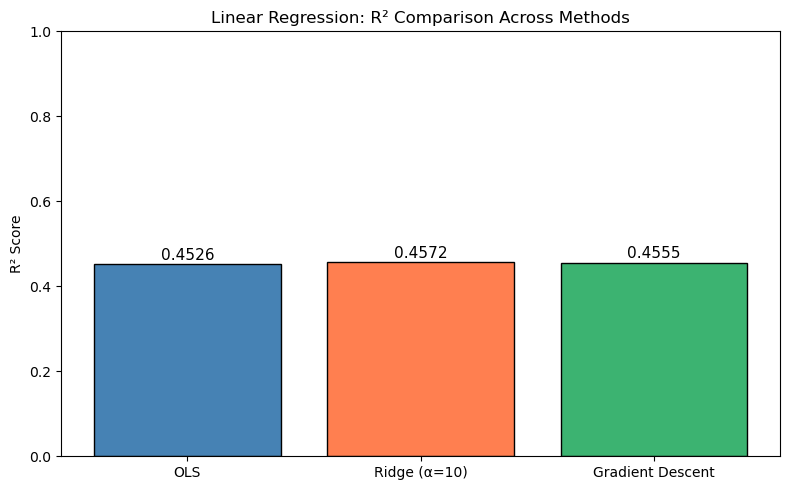

In [16]:
methods = ['OLS', 'Ridge (α=10)', 'Gradient Descent']
r2_scores = [r2_ols, r2_ridge, r2_gd]

for method, score in zip(methods, r2_scores):
    print(f"{method:25s} R² = {score:.4f}")

plt.figure(figsize=(8, 5))
bars = plt.bar(methods, r2_scores, color=['steelblue', 'coral', 'mediumseagreen'],
               edgecolor='black')
plt.ylim(0, 1)
plt.ylabel('R² Score')
plt.title('Linear Regression: R² Comparison Across Methods')
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Visualizing Predictions vs Actual 

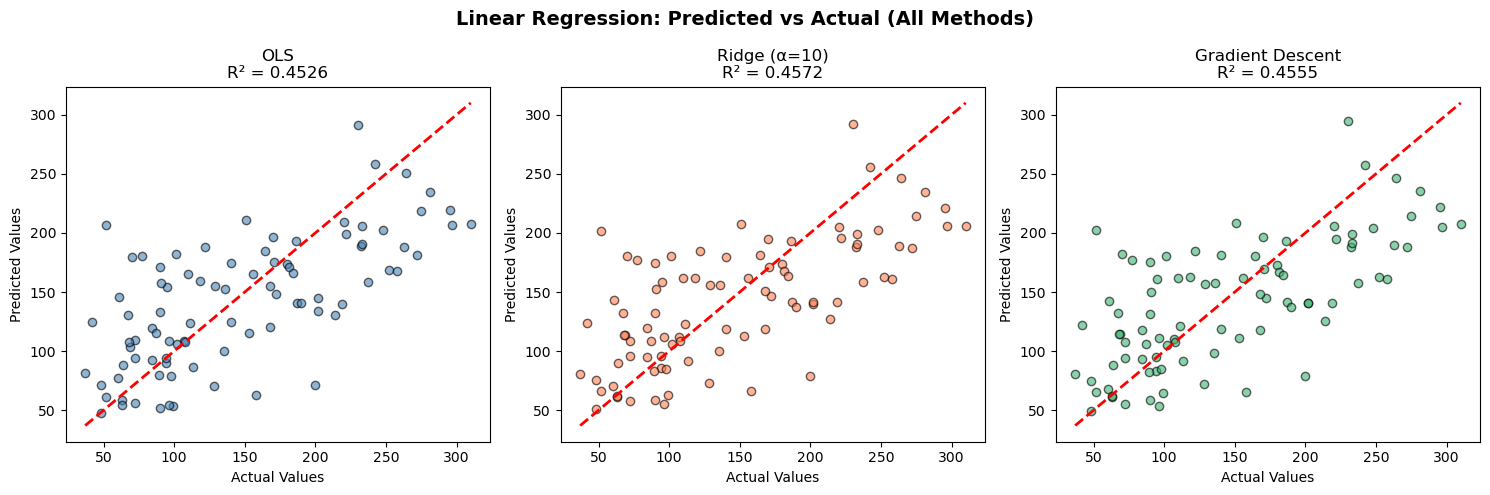

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [ols_model, ridge_model, gd_model]
titles = ['OLS', 'Ridge (α=10)', 'Gradient Descent']
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, model, title, color in zip(axes, models, titles, colors):
    y_pred = model.predict(X_test_scaled)
    r2 = model.score(X_test_scaled, y_test)
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, edgecolors='k')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.set_title(f'{title}\nR² = {r2:.4f}')

plt.suptitle('Linear Regression: Predicted vs Actual (All Methods)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- **OLS** achieves R² = 0.4526 using the exact closed-form normal equation. There is no iteration needed
- **Ridge (α=10)** achieves R² = 0.4572, slightly *higher* than OLS. The L2 regularization is helping by reducing overfitting on the training set
- **Gradient Descent** achieves R² = 0.4555, converging to a solution very close to OLS as expected. This confirms our iterative implementation is correct
- All three methods perform similarly, which validates that our from-scratch implementations are working correctly
- The scatter plots show all three models make predictions that positively correlate with actual values, with similar spread around the perfect prediction line
- R² of ~0.45 means the model explains roughly 45% of the variance in diabetes progression, which is reasonable for a linear model on this dataset since there are likely non-linear relationships between physiological features and disease progression
- More complex models like decision trees or neural networks would likely capture these non-linearities and achieve higher R²